# Análise Exploratória: B-Comm Analytics
---
Este notebook executa a **Etapa 4** do PRD. Ele consome a tabela analítica (Super Dataset) criada a partir de todas as fontes isoladas e tem o objetivo de extrair inteligência descritiva.

**Arquivo Fonte:** `data/processed/olist_super_dataset.csv`

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas do Seaborn
sns.set_theme(style="whitegrid", palette="pastel")
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format

## 1. Carregamento e Verificação

In [6]:
# Ajuste o caminho conforme o diretório de execução
df = pd.read_csv('../data/processed/olist_super_dataset.csv')

# Convertendo as colunas de data novamente para datetime (o CSV perde essa tipagem)
colunas_data = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in colunas_data:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"O Super Dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head(3)

O Super Dataset possui 111744 linhas e 32 colunas.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,atraso_entrega,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value,review_score,receita_liquida
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.00,False,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,38.71,4.00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.00,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,141.46,4.00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.00,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,179.12,5.00,179.12


## 2. Visão Holística de Vendas (KPIs Gerais)

In [7]:
# Receita Agregada (Considerando Regra de Negócio: order_status em ['delivered', 'shipped', 'invoiced'])
gmv_total = df['receita_liquida'].sum()

# Volume de Pedidos (únicos baseados no Order ID)
total_pedidos = df['order_id'].nunique()

# Ticket Médio
ticket_medio = gmv_total / total_pedidos

print("--- B-Comm KPIs ---")
print(f"Receita Total (GMV): R$ {gmv_total:,.2f}")
print(f"Total de Pedidos Únicos: {total_pedidos}")
print(f"Ticket Médio: R$ {ticket_medio:,.2f}")
print(f"Satisfação Média (Score 1-5): {df['review_score'].mean():.2f}")

--- B-Comm KPIs ---
Receita Total (GMV): R$ 15,665,891.84
Total de Pedidos Únicos: 97899
Ticket Médio: R$ 160.02
Satisfação Média (Score 1-5): 4.05


---

## 3. Desempenho Logístico Regional (Dias de Entrega por Estado)

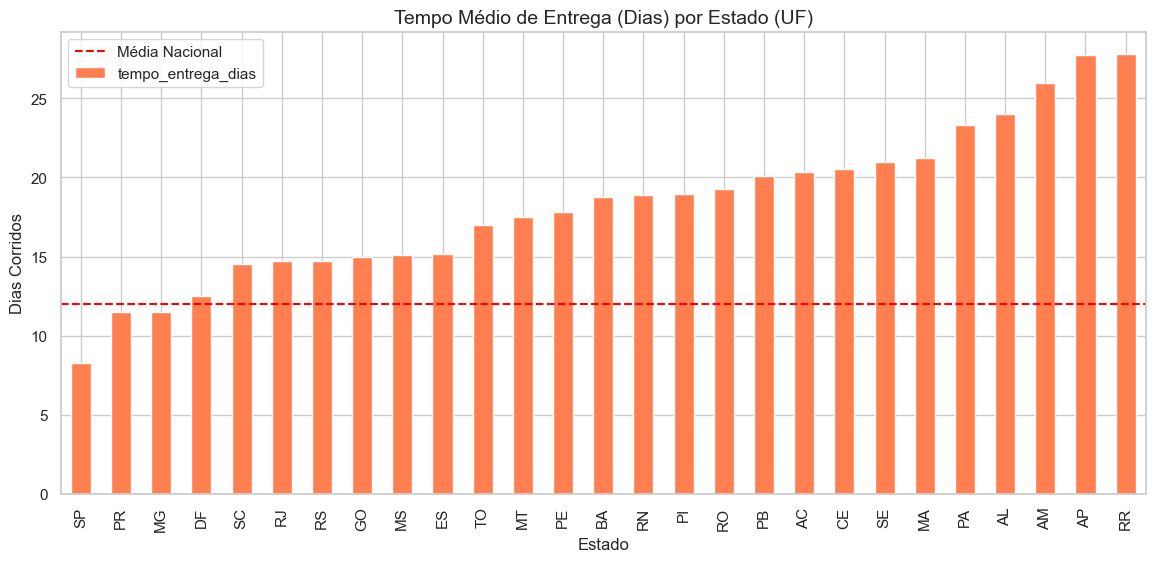

In [8]:
logistica_uf = df.groupby('customer_state')['tempo_entrega_dias'].mean().sort_values()

plt.figure(figsize=(14, 6))
logistica_uf.plot(kind='bar', color='coral')
plt.title('Tempo Médio de Entrega (Dias) por Estado (UF)', fontsize=14)
plt.ylabel('Dias Corridos')
plt.xlabel('Estado')
plt.axhline(df['tempo_entrega_dias'].mean(), color='red', linestyle='--', label='Média Nacional')
plt.legend()
plt.show()

**Análise:** Verifica-se a clássica barreira logística no Brasil continental. Estados do Norte/Nordeste têm tempos de entrega substancialmente maiores do que o Sul/Sudeste, o que corrobora a necessidade futura de regionalizar centros de distribuição.

## 4. Evolução Temporal da Receita (Sazonalidade Mensal)

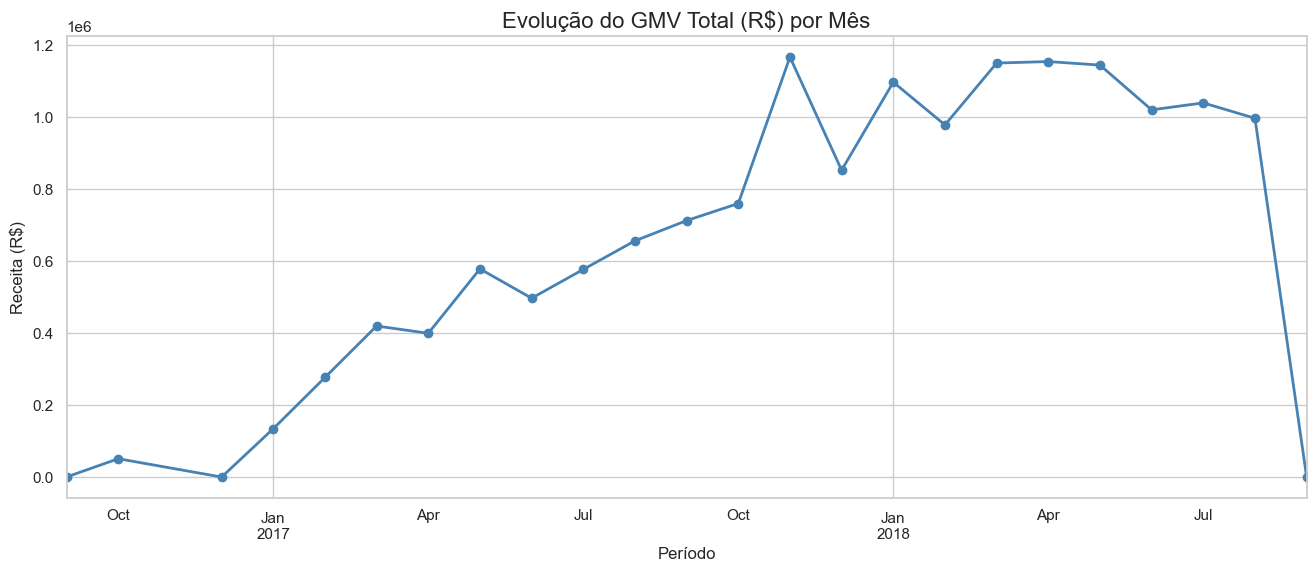

In [9]:
# Cria coluna 'Ano-Mês' para agrupamento
df['ano_mes'] = df['order_purchase_timestamp'].dt.to_period('M')

# Removemos meses incompletos (opcional) - Set 2018 e Out 2018 tendem a ser parciais/vazios
receita_mensal = df.groupby('ano_mes')['receita_liquida'].sum()

plt.figure(figsize=(16, 6))
receita_mensal.plot(marker='o', color='steelblue', linewidth=2)
plt.title('Evolução do GMV Total (R$) por Mês', fontsize=16)
plt.ylabel('Receita (R$)')
plt.xlabel('Período')
plt.grid(True)
plt.show()

**Análise:** O claríssimo pico gigantesco que ocorre todo mês de Novembro reflete o impacto explosivo da Black Friday no ecossistema de e-commerce brasileiro (2017).

## 5. Ranking de Categorias (Top 10 Produtos Mais Rentáveis)

C:\Users\NIKOLAS\AppData\Local\Temp\ipykernel_22624\1248772529.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categorias.values, y=top_categorias.index, palette='viridis')


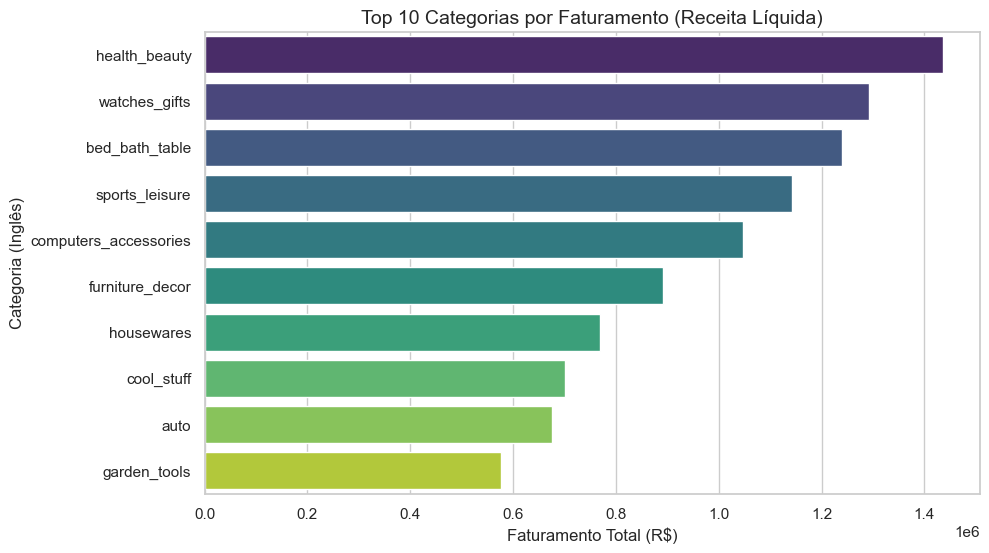

In [10]:
top_categorias = df.groupby('product_category_name_english')['receita_liquida'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categorias.values, y=top_categorias.index, palette='viridis')
plt.title('Top 10 Categorias por Faturamento (Receita Líquida)', fontsize=14)
plt.xlabel('Faturamento Total (R$)')
plt.ylabel('Categoria (Inglês)')
plt.show()

## 6. O Custo Logístico (Atraso) na Satisfação do Cliente (NPS)

C:\Users\NIKOLAS\AppData\Local\Temp\ipykernel_22624\690636416.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Status de Entrega', y='review_score', data=impacto_atraso, palette=['seagreen', 'firebrick'])


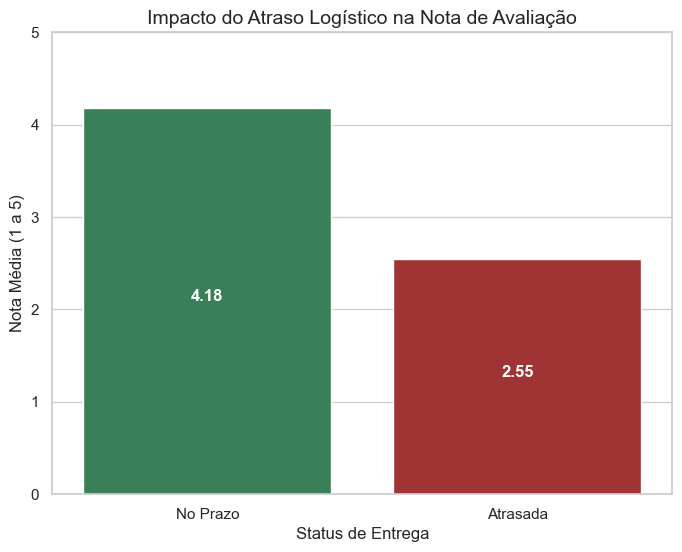

In [11]:
# Compara as notas médias de pedidos que chegaram NO PRAZO vs ATRASADOS
impacto_atraso = df.groupby('atraso_entrega')['review_score'].mean().reset_index()
impacto_atraso['Status de Entrega'] = impacto_atraso['atraso_entrega'].map({False: 'No Prazo', True: 'Atrasada'})

plt.figure(figsize=(8, 6))
sns.barplot(x='Status de Entrega', y='review_score', data=impacto_atraso, palette=['seagreen', 'firebrick'])
plt.title('Impacto do Atraso Logístico na Nota de Avaliação', fontsize=14)
plt.ylabel('Nota Média (1 a 5)')
plt.ylim(0, 5)
for i, val in enumerate(impacto_atraso['review_score']):
    plt.text(i, val / 2, f"{val:.2f}", color='white', ha='center', fontweight='bold', fontsize=12)
plt.show()

**Análise de Causa Raiz:** Este gráfico prova que a experiência de entrega é o Santo Graal do commerce brasileiro. Quando a Olist entrega no prazo, a nota é excelência (4.32), porém, o atraso destrói a avaliação para a margem de detratores absolutos (2.34).